# Pristine-silicon glancing-incidence ptychography in 1D

This notebook asks one deliberately narrow question: can diffraction from the full **1000 Å-long silicon slab** refine a poor set of coordinates when the crystal model is known? The inverse model assumes diamond silicon, the approximate (100) orientation and termination, and a broad material box. It does not import the forward atom coordinates.

This is therefore **crystallographic refinement, not lattice discovery**. The fixed Keating bond/angle graph encodes the diamond topology. What is inferred is the global unit-cell phase, strain, orientation correction, and bounded local displacements.

To make that distinction visible, the coordinate start is deliberately poor: 1.7 Å axial phase error, 1.2% axial strain, shear and transverse strain, 0.45° rotation, and 0.18 Å RMS random local disorder. The reconstruction is separated into three auditable stages:

1. a physics-only Keating relaxation restores plausible bond lengths and angles without seeing diffraction;
2. a training-only crystallographic search registers phase, residual strain, and rotation;
3. differentiable ptychographic refinement fits the remaining global and local coordinates.

Absolute axial unit-cell phase is nearly a translation gauge for a long pristine slab illuminated far from its ends. Structural comparisons remove only that axial gauge. Depth is never gauge-shifted because doing so would change the finite surface termination and hide surface rows.

In [1]:
%matplotlib inline
from pathlib import Path
from dataclasses import replace
import sys

repo_root = Path.cwd()
if not (repo_root / "wide_angle_propagation").is_dir():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import abtem
from ase import Atoms
from ase.build import bulk
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import optax
from IPython.display import Image, display
from scipy.ndimage import shift as shift_image
from scipy.spatial import cKDTree

from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel_1d,
    energy2wavelength,
)
from wide_angle_propagation.ptychography_1d import (
    GlancingScan1D,
    load_glancing_scan_1d,
    normalized_amplitude_loss_1d,
    save_glancing_scan_1d,
    simulate_glancing_scan_1d,
)
from wide_angle_propagation.ptychography_atoms_1d import make_si_atom_template_1d
from wide_angle_propagation.ptychography_crystal_1d import (
    keating_lattice_energy_1d,
    load_crystalline_defect_reconstruction_1d,
    make_crystalline_host_model_1d,
    reconstruct_crystalline_host_1d,
    render_crystalline_host_1d,
    save_crystalline_defect_reconstruction_1d,
    transform_crystalline_host_1d,
)
from wide_angle_propagation.sideview_geometry import make_tilted_gaussian_beam_1d

## 1. Independent full-slab forward model

The data are generated before the inverse model is constructed. As in the side-view viewer, the finite specimen is 1000 Å long and 50 Å deep, and the probe lands from 400–600 Å so that the reflected beam develops over hundreds of angstroms.

In [2]:
energy_eV = 30_000.0
glancing_angle_deg = 2.0
beam_tilt_rad = -np.deg2rad(glancing_angle_deg)
beam_waist_A = 3.0
propagation_length_A = 1000.0
slab_depth_A, vacuum_above_A, vacuum_below_A = 50.0, 40.0, 20.0
si_lattice_A = 5.431
si_bond_A = si_lattice_A * np.sqrt(3.0) / 4.0

si_unit = bulk("Si", "diamond", a=si_lattice_A, cubic=True)
surface_clearance_A = si_lattice_A / 8.0
surface_global_A = vacuum_below_A + slab_depth_A
transverse_extent_A = vacuum_below_A + slab_depth_A + vacuum_above_A
repeated = si_unit.repeat((
    int(np.ceil(slab_depth_A / si_lattice_A)) + 1,
    1,
    int(np.ceil(propagation_length_A / si_lattice_A)) + 1,
))
positions = repeated.positions
inside = (
    (positions[:, 0] <= slab_depth_A - surface_clearance_A + 1e-9)
    & (positions[:, 2] < propagation_length_A - 1e-9)
)
positions = positions[inside].copy()
positions[:, 0] = surface_global_A - surface_clearance_A - positions[:, 0]
si_slab = Atoms(
    symbols=["Si"] * len(positions),
    positions=positions,
    cell=(transverse_extent_A, si_lattice_A, propagation_length_A),
    pbc=(False, True, False),
)

builder = abtem.Potential(
    si_slab,
    sampling=(0.115, 0.20),
    slice_thickness=float(si_unit.cell.lengths()[1]),
    projection="finite",
    parametrization="lobato",
    plane="xz",
    periodic=False,
    device="cpu",
)
finite_projected = np.asarray(builder.build(lazy=False).array)[0]
du, ds = (float(value) for value in builder.sampling)
truth_potential = finite_projected.T / float(si_unit.cell.lengths()[1])
n_s, n_u = truth_potential.shape
s_A = np.arange(n_s) * ds
u_A = np.arange(n_u) * du - surface_global_A
print({
    "potential shape": truth_potential.shape,
    "sampling Å": (ds, du),
    "explicit forward Si atoms": len(si_slab),
    "forward length Å": float(s_A[-1]),
})

{'potential shape': (5000, 957), 'sampling Å': (0.2, 0.11494252873563218), 'explicit forward Si atoms': 13635, 'forward length Å': 999.8000000000001}


## 2. Simulate once, save, and reload the diffraction

The NPZ file is the boundary between forward simulation and reconstruction. It contains intensities and scan geometry, not atom coordinates or the potential.

In [3]:
result_directory = repo_root / "notebook_results/sideview_glancing_ptychography_1d"
result_directory.mkdir(parents=True, exist_ok=True)
dataset_path = result_directory / "viewer_1000A_scan_400_600A.npz"
scan_coordinates_A = np.linspace(400.0, 600.0, 41)
beam_centres_A = -scan_coordinates_A * np.tan(beam_tilt_rad)
input_probes = jnp.stack([
    make_tilted_gaussian_beam_1d(
        jnp.asarray(u_A), energy_eV, waist=beam_waist_A,
        center=float(center), tilt=beam_tilt_rad,
    )
    for center in beam_centres_A
]).astype(jnp.complex128)
kernel = angular_spectrum_propagation_kernel_1d(n_u, du, ds, energy_eV)
full_window_starts = jnp.zeros(len(scan_coordinates_A), dtype=jnp.int32)

if not dataset_path.exists():
    intensities = simulate_glancing_scan_1d(
        truth_potential, input_probes, full_window_starts, n_s,
        kernel, ds, energy_eV,
    )
    wavelength_A = float(energy2wavelength(energy_eV))
    frequencies = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
    detector_angles = 1e3 * np.arcsin(
        np.clip(wavelength_A * frequencies, -1.0, 1.0)
    )
    save_glancing_scan_1d(dataset_path, GlancingScan1D(
        intensities,
        full_window_starts,
        jnp.asarray(scan_coordinates_A),
        jnp.asarray(detector_angles),
        {
            "specimen": "finite pristine silicon slab",
            "energy_eV": energy_eV,
            "glancing_angle_deg": glancing_angle_deg,
            "beam_waist_A": beam_waist_A,
            "propagation_length_A": propagation_length_A,
            "slab_depth_A": slab_depth_A,
            "sampling_ds_A": ds,
            "sampling_du_A": du,
            "grid_shape": [n_s, n_u],
            "scan_landing_range_A": [400.0, 600.0],
            "forward_potential": "finite Lobato abTEM",
            "propagator": "angular spectrum",
        },
    ))

scan = load_glancing_scan_1d(dataset_path)
print(dataset_path, f"{dataset_path.stat().st_size / 1e6:.2f} MB")
display(scan.metadata)

/home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_ptychography_1d/viewer_1000A_scan_400_600A.npz 0.31 MB


{'beam_waist_A': 3.0,
 'energy_eV': 30000.0,
 'explicit_si_atoms': 13635,
 'forward_potential': 'finite Lobato abTEM projected potential',
 'glancing_angle_deg': 2.0,
 'grid_shape': [5000, 957],
 'propagation_length_A': 1000.0,
 'propagator': 'angular spectrum',
 'runtime_s': 1.10115647315979,
 'sampling_ds_A': 0.2,
 'sampling_du_A': 0.11494252873563218,
 'scan_landing_range_A': [400.0, 600.0],
 'slab_depth_A': 50.0,
 'specimen': 'pristine finite silicon slab',
 'vacuum_above_A': 40.0,
 'vacuum_below_A': 20.0}

## 3. Confirm the reflected signal and choose a loose volume

The inverse box retains 100 Å axial buffers on both sides of the scan range and the full 50 Å material depth. It is intentionally larger than the bright interaction core, but still excludes the remote specimen ends. The exact-crop result below is a truncation reference, not a reconstruction target.

{'loose material box Å': [[100.0, 900.0], [-50.0, 0.0]], 'held-out exact axial-crop amplitude NRMSE': 0.011409962418741204}


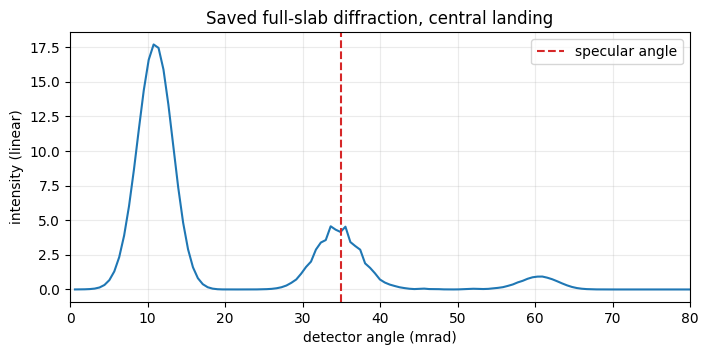

In [4]:
center_scan = len(scan.scan_coordinates) // 2
positive_angles = np.asarray(scan.detector_angles) > 0
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(
    np.asarray(scan.detector_angles)[positive_angles],
    np.asarray(scan.intensities)[center_scan, positive_angles],
)
ax.axvline(
    1e3 * np.deg2rad(glancing_angle_deg), color="tab:red", ls="--",
    label="specular angle",
)
ax.set(
    xlim=(0, 80), xlabel="detector angle (mrad)",
    ylabel="intensity (linear)",
    title="Saved full-slab diffraction, central landing",
)
ax.legend()
ax.grid(alpha=0.25)

validation_indices = np.arange(0, len(scan.scan_coordinates), 5)
training_indices = np.setdiff1d(
    np.arange(len(scan.scan_coordinates)), validation_indices
)
inverse_s_bounds_A = np.asarray([100.0, 900.0])
inverse_u_bounds_A = np.asarray([-50.0, 0.0])
crop_start, crop_stop = (
    int(round(value / ds)) for value in inverse_s_bounds_A
)
crop_s_A = s_A[crop_start:crop_stop]
crop_n_s = crop_stop - crop_start
crop_probes = jnp.fft.ifft(
    jnp.fft.fft(input_probes, axis=-1) * kernel**crop_start,
    axis=-1,
)
crop_starts = jnp.zeros(len(scan.scan_coordinates), dtype=jnp.int32)
truth_crop_potential = jnp.asarray(truth_potential[crop_start:crop_stop])
exact_crop_prediction = simulate_glancing_scan_1d(
    truth_crop_potential, crop_probes, crop_starts, crop_n_s,
    kernel, ds, energy_eV,
)
exact_crop_nrmse = float(jnp.sqrt(normalized_amplitude_loss_1d(
    exact_crop_prediction[validation_indices],
    scan.intensities[validation_indices],
)))
print({
    "loose material box Å": [
        inverse_s_bounds_A.tolist(), inverse_u_bounds_A.tolist()
    ],
    "held-out exact axial-crop amplitude NRMSE": exact_crop_nrmse,
})

## 4. Build the known diamond topology, then spoil its coordinates

The host is generated independently from the silicon lattice constant and orientation. Its axial origin is the lower edge of the loose box rather than the simulation origin. This already encodes strong information: atom count from volume, diamond connectivity, the Si bond length, and the (100) surface termination.

The coordinates inside the reconstruction support are then deliberately distorted well beyond the previous near-answer initialization. The fixed graph remains the prior, but neither the raw phase, affine transform, nor individual active coordinates are close to the forward sites. Each probe is treated as a **post-landing half-ray**, not an infinite line: no bulk site before that scan's landing coordinate can update. Consequently the union is empty before 400 Å, grows as scans land from 400–600 Å, and continues into the slab after 600 Å. A smooth transverse taper extends to four input waists around each valid half-ray. This deliberately neglects the extremely weak pre-landing Gaussian tail at the surface; retaining that tail would give a soft, low-sensitivity footprint before 400 Å rather than a strict causal support. Grey coordinates remain frozen at the assumed host prior and are neither scored nor claimed as recovered.

{'volume-derived host sites': 10915, 'sparse Keating bonds': 15903, 'sparse Keating angles': 36327, 'raw phase error Å': 1.7, 'raw axial strain %': 1.2, 'raw rotation deg': 0.45, 'raw local displacement RMS Å': 0.17189809386303875, 'fully frozen host sites': 8099, 'fully active host sites': 2172, 'effective update sites': 2505.3538124925117, 'effective sites before 400 Å': 0.0, 'effective sites from 400–600 Å': 721.4521315234184, 'effective sites after 600 Å': 1783.9016809690931, 'support radii Å (full, frozen)': [7.5, 12.0]}


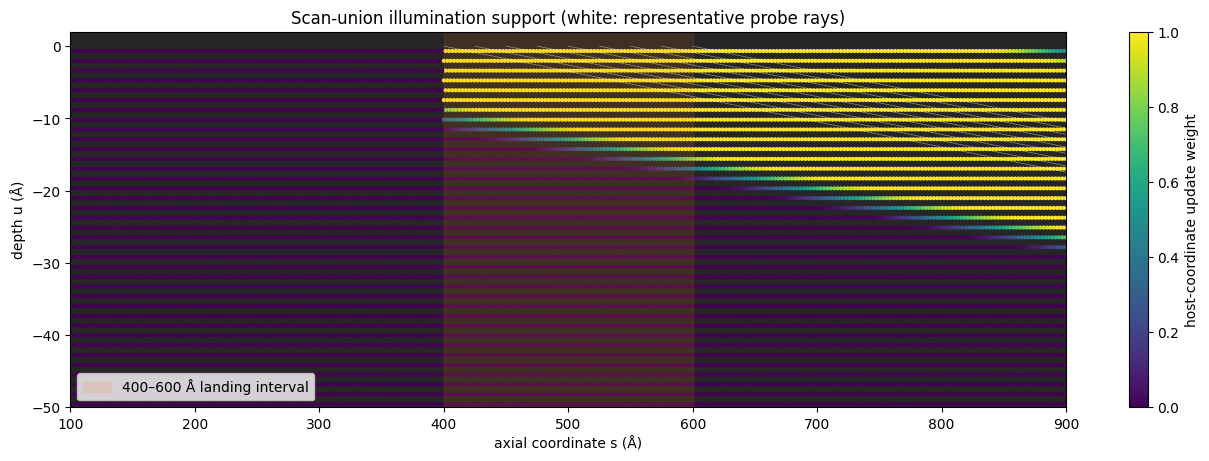

In [5]:
inverse_repeated = si_unit.repeat((
    int(np.ceil(slab_depth_A / si_lattice_A)) + 2,
    1,
    int(np.ceil(np.diff(inverse_s_bounds_A)[0] / si_lattice_A)) + 2,
))
inverse_positions = inverse_repeated.positions
latent_host_reference_A = np.stack([
    inverse_s_bounds_A[0] + inverse_positions[:, 2],
    inverse_positions[:, 1],
    -surface_clearance_A - inverse_positions[:, 0],
], axis=-1)
reference_inside = (
    (latent_host_reference_A[:, 0] >= crop_s_A[0])
    & (latent_host_reference_A[:, 0] <= crop_s_A[-1])
    & (latent_host_reference_A[:, 2] >= inverse_u_bounds_A[0])
    & (latent_host_reference_A[:, 2] <= inverse_u_bounds_A[1])
)
latent_host_reference_A = latent_host_reference_A[reference_inside]
host_ray_u_A = (
    beam_centres_A[None, :]
    + latent_host_reference_A[:, 0, None] * np.tan(beam_tilt_rad)
)
host_ray_is_post_landing = (
    latent_host_reference_A[:, 0, None] >= scan_coordinates_A[None, :]
)
host_ray_distance_A = np.min(
    np.where(
        host_ray_is_post_landing,
        np.abs(latent_host_reference_A[:, 2, None] - host_ray_u_A),
        np.inf,
    ),
    axis=1,
)
update_inner_radius_A = 2.5 * beam_waist_A
update_outer_radius_A = 4.0 * beam_waist_A
update_fraction = np.clip(
    (update_outer_radius_A - host_ray_distance_A)
    / (update_outer_radius_A - update_inner_radius_A),
    0.0, 1.0,
)
host_update_weights = update_fraction**2 * (3.0 - 2.0 * update_fraction)
before_first_landing = (
    latent_host_reference_A[:, 0] < scan_coordinates_A[0]
)
within_landing_interval = (
    (latent_host_reference_A[:, 0] >= scan_coordinates_A[0])
    & (latent_host_reference_A[:, 0] <= scan_coordinates_A[-1])
)
after_last_landing = (
    latent_host_reference_A[:, 0] > scan_coordinates_A[-1]
)
assert np.all(host_update_weights[before_first_landing] == 0.0)
assert np.any(host_update_weights[within_landing_interval] > 0.0)
assert np.any(host_update_weights[after_last_landing] > 0.0)
material_bounds_A = np.asarray([
    [crop_s_A[0], crop_s_A[-1]], inverse_u_bounds_A,
])
si_template = make_si_atom_template_1d(
    ds, du, cutoff_A=4.0, projection_width_A=si_lattice_A
)
topology_model = make_crystalline_host_model_1d(
    jnp.asarray(crop_s_A),
    jnp.asarray(u_A),
    si_template,
    latent_host_reference_A,
    material_bounds_A,
    host_update_weights=host_update_weights,
    equilibrium_bond_length_A=si_bond_A,
    bond_cutoff_A=2.65,
    host_maximum_displacement_A=0.5,
    metadata={
        "host": "pristine diamond Si",
        "initial_axial_origin_A": float(inverse_s_bounds_A[0]),
        "surface_termination": "known (100) plane, top host at -a/8",
    },
)

coordinate_rng = np.random.default_rng(73)
random_start_displacement_A = np.clip(
    coordinate_rng.normal(0.0, 0.18, (len(latent_host_reference_A), 2)),
    -0.35,
    0.35,
)
imposed_start_translation_A = np.asarray([1.7, 0.0])
imposed_start_strain = np.asarray([
    [0.012, 0.002],
    [0.001, -0.006],
])
imposed_start_rotation_deg = 0.45
raw_initial_host_A = transform_crystalline_host_1d(
    jnp.asarray(latent_host_reference_A),
    jnp.asarray(imposed_start_translation_A),
    jnp.asarray(imposed_start_strain),
    jnp.deg2rad(imposed_start_rotation_deg),
    jnp.asarray(random_start_displacement_A),
    host_update_weights,
)
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
site_artist = ax.scatter(
    latent_host_reference_A[:, 0], latent_host_reference_A[:, 2],
    c=host_update_weights, s=4, cmap="viridis", vmin=0.0, vmax=1.0,
)
for landing_A in scan_coordinates_A[::5]:
    post_landing_s_A = crop_s_A[crop_s_A >= landing_A]
    ax.plot(
        post_landing_s_A,
        (landing_A - post_landing_s_A) * np.tan(glancing_angle_deg * np.pi / 180),
        color="white", lw=0.45, alpha=0.5,
    )
ax.axvspan(
    scan_coordinates_A[0], scan_coordinates_A[-1],
    color="tab:orange", alpha=0.12, label="400–600 Å landing interval",
)
ax.set(
    xlim=tuple(inverse_s_bounds_A), ylim=(-50.0, 2.0),
    xlabel="axial coordinate s (Å)", ylabel="depth u (Å)",
    title="Scan-union illumination support (white: representative probe rays)",
)
ax.set_facecolor("0.15")
ax.legend(loc="lower left")
fig.colorbar(site_artist, ax=ax, label="host-coordinate update weight")
print({
    "volume-derived host sites": len(latent_host_reference_A),
    "sparse Keating bonds": len(topology_model.host_bonds),
    "sparse Keating angles": len(topology_model.host_angles),
    "raw phase error Å": imposed_start_translation_A[0],
    "raw axial strain %": 100 * imposed_start_strain[0, 0],
    "raw rotation deg": imposed_start_rotation_deg,
    "raw local displacement RMS Å": float(np.sqrt(np.mean(
        random_start_displacement_A**2
    ))),
    "fully frozen host sites": int(np.sum(host_update_weights == 0.0)),
    "fully active host sites": int(np.sum(host_update_weights == 1.0)),
    "effective update sites": float(np.sum(host_update_weights)),
    "effective sites before 400 Å": float(np.sum(
        host_update_weights[before_first_landing]
    )),
    "effective sites from 400–600 Å": float(np.sum(
        host_update_weights[within_landing_interval]
    )),
    "effective sites after 600 Å": float(np.sum(
        host_update_weights[after_last_landing]
    )),
    "support radii Å (full, frozen)": [
        update_inner_radius_A, update_outer_radius_A
    ],
})

## 5. Physics-only Keating pre-relaxation

A fixed graph is useful only if its coordinates can return to a physical lattice. This stage sees no diffraction. It fits a global in-plane strain correction and one bounded local displacement per illuminated site using only illumination-gated Keating bond-stretch and tetrahedral-angle energy. Sites outside the scan-union wedge remain at the assumed, unscored diamond-host prior. Rigid translation and rotation remain unresolved because the elastic energy is invariant to them; diffraction must determine those degrees of freedom later.

{'raw held-out amplitude NRMSE': 0.3929738689217758, 'physics-relaxed held-out amplitude NRMSE': 0.04687622203619006, 'final Keating objective': 0.00014327744675629077, 'final physics-only bond spread Å': 0.007204875161084098, 'diffraction used during relaxation': False}


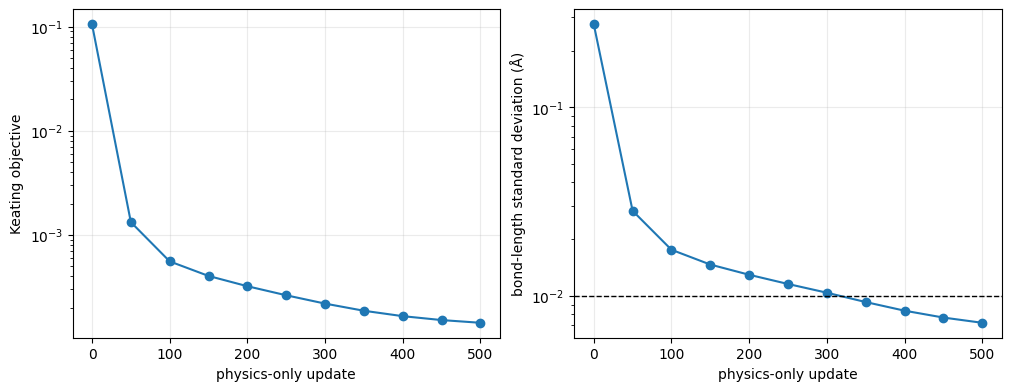

In [6]:
def predict_host(host_positions, indices):
    potential = render_crystalline_host_1d(topology_model, host_positions)
    return simulate_glancing_scan_1d(
        potential,
        crop_probes[indices],
        crop_starts[indices],
        crop_n_s,
        kernel,
        ds,
        energy_eV,
    )

raw_initial_prediction = predict_host(
    raw_initial_host_A, jnp.arange(len(scan.scan_coordinates))
)
raw_validation_nrmse = float(jnp.sqrt(normalized_amplitude_loss_1d(
    raw_initial_prediction[validation_indices],
    scan.intensities[validation_indices],
)))

relaxation_parameters = {
    "strain": jnp.zeros((2, 2)),
    "local": jnp.zeros((len(raw_initial_host_A), 2)),
}
relaxation_optimizer = optax.multi_transform(
    {
        "strain": optax.adam(2e-3),
        "local": optax.adam(1e-2),
    },
    {"strain": "strain", "local": "local"},
)
relaxation_state = relaxation_optimizer.init(relaxation_parameters)
elastic_occupancy = jnp.asarray(host_update_weights)
unit_species = jnp.ones((len(raw_initial_host_A), 1))

def relaxation_objective(parameters):
    positions = transform_crystalline_host_1d(
        raw_initial_host_A,
        jnp.zeros(2),
        parameters["strain"],
        jnp.asarray(0.0),
        parameters["local"],
        host_update_weights,
    )
    elastic = keating_lattice_energy_1d(
        positions,
        elastic_occupancy,
        unit_species,
        topology_model.host_bonds,
        topology_model.host_angles,
        topology_model.species_bond_lengths_A,
    )
    local_penalty = jnp.sum(
        elastic_occupancy[:, None] * parameters["local"] ** 2
    ) / jnp.maximum(2.0 * jnp.sum(elastic_occupancy), 1.0)
    return elastic + 1e-5 * local_penalty

@jax.jit
def relaxation_step(parameters, state):
    loss, gradients = jax.value_and_grad(relaxation_objective)(parameters)
    updates, state = relaxation_optimizer.update(
        gradients, state, parameters
    )
    parameters = optax.apply_updates(parameters, updates)
    parameters = {
        "strain": jnp.clip(parameters["strain"], -0.03, 0.03),
        "local": jnp.clip(parameters["local"], -0.6, 0.6),
    }
    return parameters, state, loss

relaxation_updates = []
relaxation_energy = []
relaxation_bond_std_A = []
for update in range(501):
    if update % 50 == 0:
        relaxed_checkpoint = transform_crystalline_host_1d(
            raw_initial_host_A,
            jnp.zeros(2),
            relaxation_parameters["strain"],
            jnp.asarray(0.0),
            relaxation_parameters["local"],
            host_update_weights,
        )
        bond_indices = np.asarray(topology_model.host_bonds)
        active_bond_mask = np.min(
            host_update_weights[bond_indices], axis=1
        ) > 0.5
        active_bond_indices = bond_indices[active_bond_mask]
        bond_lengths = np.linalg.norm(
            np.asarray(relaxed_checkpoint)[active_bond_indices[:, 1]]
            - np.asarray(relaxed_checkpoint)[active_bond_indices[:, 0]],
            axis=1,
        )
        relaxation_updates.append(update)
        relaxation_energy.append(float(
            relaxation_objective(relaxation_parameters)
        ))
        relaxation_bond_std_A.append(float(np.std(bond_lengths)))
    if update < 500:
        relaxation_parameters, relaxation_state, _ = relaxation_step(
            relaxation_parameters, relaxation_state
        )

physics_relaxed_host_A = transform_crystalline_host_1d(
    raw_initial_host_A,
    jnp.zeros(2),
    relaxation_parameters["strain"],
    jnp.asarray(0.0),
    relaxation_parameters["local"],
    host_update_weights,
)
physics_relaxed_prediction = predict_host(
    physics_relaxed_host_A, jnp.arange(len(scan.scan_coordinates))
)
physics_relaxed_validation_nrmse = float(jnp.sqrt(
    normalized_amplitude_loss_1d(
        physics_relaxed_prediction[validation_indices],
        scan.intensities[validation_indices],
    )
))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
axes[0].semilogy(relaxation_updates, relaxation_energy, marker="o")
axes[0].set(xlabel="physics-only update", ylabel="Keating objective")
axes[1].semilogy(relaxation_updates, relaxation_bond_std_A, marker="o")
axes[1].axhline(0.01, color="k", ls="--", lw=1)
axes[1].set(
    xlabel="physics-only update", ylabel="bond-length standard deviation (Å)"
)
for axis in axes:
    axis.grid(alpha=0.25)
print({
    "raw held-out amplitude NRMSE": raw_validation_nrmse,
    "physics-relaxed held-out amplitude NRMSE": (
        physics_relaxed_validation_nrmse
    ),
    "final Keating objective": relaxation_energy[-1],
    "final physics-only bond spread Å": relaxation_bond_std_A[-1],
    "diffraction used during relaxation": False,
})

## 6. Training-only crystallographic registration

Keating relaxation restores local geometry but cannot determine rigid phase or rotation. A small search over one axial unit cell, ±0.2% residual axial strain, and ±0.75° rotation now uses only the training scans. Every candidate transform is blended through the same illumination weights, so frozen sites cannot move during registration. The held-out scans are evaluated after selecting the minimum.

{'selected phase correction Å': -2.2629166666666665, 'selected residual axial strain': 0.002, 'selected rotation correction deg': 0.0, 'held-out registered amplitude NRMSE': 0.04271771098379138}


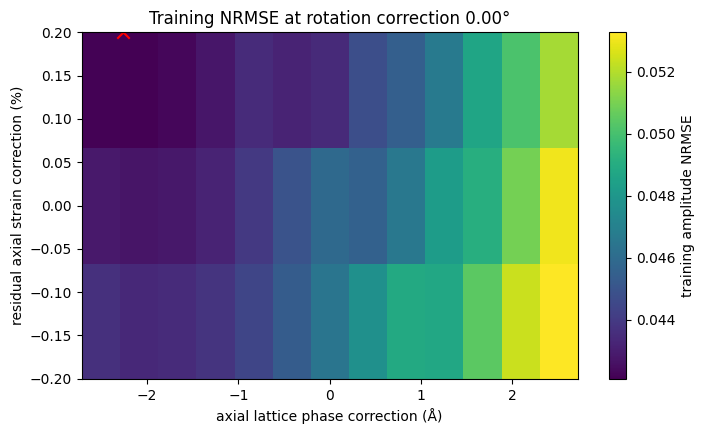

In [7]:
@jax.jit
def coarse_training_nrmse(phase_strain_rotation):
    host_positions = transform_crystalline_host_1d(
        physics_relaxed_host_A,
        jnp.asarray([phase_strain_rotation[0], 0.0]),
        jnp.asarray([[phase_strain_rotation[1], 0.0], [0.0, 0.0]]),
        jnp.deg2rad(phase_strain_rotation[2]),
        jnp.zeros((len(physics_relaxed_host_A), 2)),
        host_update_weights,
    )
    prediction = predict_host(host_positions, training_indices)
    return jnp.sqrt(normalized_amplitude_loss_1d(
        prediction, scan.intensities[training_indices]
    ))

phase_grid_A = np.linspace(-si_lattice_A / 2, si_lattice_A / 2, 13)
strain_grid = np.asarray([-0.002, 0.0, 0.002])
rotation_grid_deg = np.linspace(-0.75, 0.75, 7)
coarse_loss = np.empty((
    len(phase_grid_A), len(strain_grid), len(rotation_grid_deg)
))
for phase_index, phase_A in enumerate(phase_grid_A):
    for strain_index, strain in enumerate(strain_grid):
        for rotation_index, rotation_deg in enumerate(rotation_grid_deg):
            coarse_loss[phase_index, strain_index, rotation_index] = float(
                coarse_training_nrmse(jnp.asarray([
                    phase_A, strain, rotation_deg
                ]))
            )
best_phase_index, best_strain_index, best_rotation_index = np.unravel_index(
    np.argmin(coarse_loss), coarse_loss.shape
)
coarse_phase_A = float(phase_grid_A[best_phase_index])
coarse_strain = float(strain_grid[best_strain_index])
coarse_rotation_deg = float(rotation_grid_deg[best_rotation_index])
registered_host_A = transform_crystalline_host_1d(
    physics_relaxed_host_A,
    jnp.asarray([coarse_phase_A, 0.0]),
    jnp.asarray([[coarse_strain, 0.0], [0.0, 0.0]]),
    jnp.deg2rad(coarse_rotation_deg),
    jnp.zeros((len(physics_relaxed_host_A), 2)),
    host_update_weights,
)
coarse_prediction = predict_host(
    registered_host_A, jnp.arange(len(scan.scan_coordinates))
)
coarse_validation_nrmse = float(jnp.sqrt(normalized_amplitude_loss_1d(
    coarse_prediction[validation_indices],
    scan.intensities[validation_indices],
)))

fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(
    coarse_loss[:, :, best_rotation_index].T,
    origin="lower",
    aspect="auto",
    extent=[
        phase_grid_A[0], phase_grid_A[-1],
        100 * strain_grid[0], 100 * strain_grid[-1],
    ],
    cmap="viridis",
)
ax.scatter(coarse_phase_A, 100 * coarse_strain, marker="x", s=80, c="red")
ax.set(
    xlabel="axial lattice phase correction (Å)",
    ylabel="residual axial strain correction (%)",
    title=f"Training NRMSE at rotation correction {coarse_rotation_deg:.2f}°",
)
fig.colorbar(image, ax=ax, label="training amplitude NRMSE")
print({
    "selected phase correction Å": coarse_phase_A,
    "selected residual axial strain": coarse_strain,
    "selected rotation correction deg": coarse_rotation_deg,
    "held-out registered amplitude NRMSE": coarse_validation_nrmse,
})

## 7. Ptychographic refinement with the Keating prior retained

The registered but independently relaxed lattice is refined for 300 updates. Updates 1–100 fit only the global transform. Updates 101–300 also release local in-plane host displacements, bounded to 0.25 Å, while the Keating term prevents the diffraction objective from destroying the Si network. Occupancies and species remain fixed exactly.

In [8]:
host_model_bounds_A = material_bounds_A.copy()
host_model_bounds_A[0] += np.asarray([-12.0, 12.0])
host_model_bounds_A[1] += np.asarray([-8.0, 8.0])
ideal_graph_model = make_crystalline_host_model_1d(
    jnp.asarray(crop_s_A),
    jnp.asarray(u_A),
    si_template,
    latent_host_reference_A,
    host_model_bounds_A,
    host_update_weights=host_update_weights,
    equilibrium_bond_length_A=si_bond_A,
    bond_cutoff_A=2.65,
    host_maximum_displacement_A=0.6,
    metadata={"host": "pristine diamond Si"},
)
crystal_model = replace(
    ideal_graph_model,
    host_reference_positions_3d=jnp.asarray(registered_host_A),
    metadata={
        "host": "pristine diamond Si",
        "loose_material_bounds_A": material_bounds_A.tolist(),
        "raw_start_phase_A": float(imposed_start_translation_A[0]),
        "raw_start_strain": imposed_start_strain.tolist(),
        "raw_start_rotation_deg": imposed_start_rotation_deg,
        "raw_start_local_rms_A": float(np.sqrt(np.mean(
            random_start_displacement_A**2
        ))),
        "physics_only_relaxation_updates": 500,
        "coarse_phase_A": coarse_phase_A,
        "coarse_strain": coarse_strain,
        "coarse_rotation_deg": coarse_rotation_deg,
    },
)

reconstruction_path = (
    result_directory / "pristine_si_post_landing_masked_v6.npz"
)
if reconstruction_path.exists():
    crystal_result = load_crystalline_defect_reconstruction_1d(
        reconstruction_path
    )
else:
    crystal_result = reconstruct_crystalline_host_1d(
        crystal_model,
        crop_probes,
        crop_starts,
        crop_n_s,
        kernel,
        ds,
        energy_eV,
        scan.intensities,
        validation_indices=validation_indices,
        updates=300,
        stage_global_end=100,
        stage_host_end=300,
        stage_defect_end=300,
        minibatch_size=4,
        validation_interval=25,
        evaluation_batch_size=5,
        learning_rate_start=5e-3,
        learning_rate_end=2e-4,
        keating_weight=0.5,
        displacement_weight=0.0,
        translation_limit_A=2.0,
        strain_limit=0.01,
        rotation_limit_deg=0.3,
        host_displacement_limit_A=0.25,
        enable_host_displacements=True,
        seed=5,
        progress=True,
        progress_description="post-landing masked pristine Si + Keating",
    )
    save_crystalline_defect_reconstruction_1d(
        reconstruction_path, crystal_result
    )
print(reconstruction_path, f"best update {crystal_result.best_update}")

/home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_ptychography_1d/pristine_si_post_landing_masked_v6.npz best update 300


## 8. Quantitative lattice checks and the axial translation gauge

The post-hoc registration searches only an **axial** rigid offset over the interpretable illumination core (update weight above 0.8). Depth is not a gauge at a finite surface: allowing a bulk-equivalent depth shift changes the termination and was the reason the previous plot appeared to lose two surface rows. Structural metrics exclude both the grey frozen volume and the soft boundary layer. This registration is used only for structural scoring and visualization.

In [9]:
latent_truth_A = np.stack([
    si_slab.positions[:, 2],
    si_slab.positions[:, 1],
    si_slab.positions[:, 0] - surface_global_A,
], axis=-1)
recovered_sites_A = np.asarray(crystal_result.host_positions_3d)
illuminated_core = host_update_weights > 0.8
recovered_core_A = recovered_sites_A[illuminated_core]
truth_tree = cKDTree(latent_truth_A)

gauge_values_A = np.linspace(-si_lattice_A, si_lattice_A, 61)
best_gauge = (np.inf, 0.0)
for gauge_s_A in gauge_values_A:
    shifted = recovered_core_A + np.asarray([gauge_s_A, 0.0, 0.0])
    median_distance = float(np.median(truth_tree.query(shifted, k=1)[0]))
    if median_distance < best_gauge[0]:
        best_gauge = (median_distance, gauge_s_A)
coarse_gauge_step_A = gauge_values_A[1] - gauge_values_A[0]
for gauge_s_A in np.linspace(
    best_gauge[1] - coarse_gauge_step_A,
    best_gauge[1] + coarse_gauge_step_A,
    41,
):
    shifted = recovered_core_A + np.asarray([gauge_s_A, 0.0, 0.0])
    median_distance = float(np.median(truth_tree.query(shifted, k=1)[0]))
    if median_distance < best_gauge[0]:
        best_gauge = (median_distance, gauge_s_A)

gauge_translation_A = np.asarray([best_gauge[1], 0.0])
aligned_core_A = recovered_core_A + np.asarray([
    gauge_translation_A[0], 0.0, gauge_translation_A[1]
])
aligned_site_distances_A = truth_tree.query(aligned_core_A, k=1)[0]
bond_indices = np.asarray(crystal_model.host_bonds)
illuminated_bond_mask = np.min(
    host_update_weights[bond_indices], axis=1
) > 0.8
illuminated_bond_indices = bond_indices[illuminated_bond_mask]
recovered_bond_lengths_A = np.linalg.norm(
    recovered_sites_A[illuminated_bond_indices[:, 1]]
    - recovered_sites_A[illuminated_bond_indices[:, 0]],
    axis=1,
)
one_species = jnp.ones((len(recovered_sites_A), 1))
keating_energy = float(keating_lattice_energy_1d(
    crystal_result.host_positions_3d,
    jnp.asarray(host_update_weights),
    one_species,
    crystal_model.host_bonds,
    crystal_model.host_angles,
    crystal_model.species_bond_lengths_A,
))
history_index = int(np.flatnonzero(
    np.asarray(crystal_result.update_history) == crystal_result.best_update
)[0])
best_local_displacement_A = np.asarray(
    crystal_result.host_displacement_history[history_index]
)
local_displacement_rms_A = float(np.sqrt(
    np.sum(host_update_weights[:, None] * best_local_displacement_A**2)
    / (2.0 * np.sum(host_update_weights))
))
heldout_nrmse = float(np.nanmin(crystal_result.validation_loss_history))
linear_intensity_nrmse = float(
    np.linalg.norm(
        np.asarray(crystal_result.predicted_intensities)
        - np.asarray(scan.intensities)
    ) / np.linalg.norm(np.asarray(scan.intensities))
)
surface_reference_u_A = float(np.max(latent_host_reference_A[:, 2]))
surface_site_indices = (
    np.isclose(latent_host_reference_A[:, 2], surface_reference_u_A, atol=1e-8)
    & illuminated_core
)
recovered_surface_u_A = float(np.median(
    recovered_sites_A[surface_site_indices, 2]
))
surface_plane_error_A = recovered_surface_u_A - surface_reference_u_A
frozen_site_mask = host_update_weights == 0.0
frozen_site_maximum_motion_A = float(np.max(np.linalg.norm(
    recovered_sites_A[frozen_site_mask] - np.asarray(raw_initial_host_A)[frozen_site_mask],
    axis=1,
)))
summary = {
    "diffraction": {
        "raw held-out amplitude NRMSE": raw_validation_nrmse,
        "physics-relaxed held-out amplitude NRMSE": physics_relaxed_validation_nrmse,
        "registered held-out amplitude NRMSE": coarse_validation_nrmse,
        "refined held-out amplitude NRMSE": heldout_nrmse,
        "all-scan linear-intensity NRMSE": linear_intensity_nrmse,
    },
    "crystal": {
        "volume-derived host sites": len(recovered_sites_A),
        "effective illuminated host sites": float(np.sum(host_update_weights)),
        "fully frozen host sites": int(np.sum(frozen_site_mask)),
        "maximum motion of frozen sites Å": frozen_site_maximum_motion_A,
        "median illuminated bond length Å": float(np.median(recovered_bond_lengths_A)),
        "illuminated bond-length standard deviation Å": float(np.std(recovered_bond_lengths_A)),
        "Si equilibrium bond length Å": si_bond_A,
        "Keating energy": keating_energy,
        "local displacement RMS Å": local_displacement_rms_A,
        "refined global strain": np.asarray(crystal_result.strain).tolist(),
        "known top surface plane Å": surface_reference_u_A,
        "recovered median top surface plane Å": recovered_surface_u_A,
        "top surface-plane error Å": surface_plane_error_A,
    },
    "post-hoc translation-gauge check": {
        "axial gauge shift Å": float(gauge_translation_A[0]),
        "median core site error Å": float(np.median(aligned_site_distances_A)),
        "90th-percentile core site error Å": float(
            np.percentile(aligned_site_distances_A, 90)
        ),
    },
}
success_gates = {
    "held-out amplitude NRMSE < 1%": heldout_nrmse < 0.01,
    "median bond error < 0.02 Å": abs(
        np.median(recovered_bond_lengths_A) - si_bond_A
    ) < 0.02,
    "bond-length standard deviation < 0.05 Å": (
        np.std(recovered_bond_lengths_A) < 0.05
    ),
    "top surface-plane error < 0.15 Å": abs(surface_plane_error_A) < 0.15,
    "gauge-aligned median core site error < 0.30 Å": (
        np.median(aligned_site_distances_A) < 0.30
    ),
    "raw start is genuinely poor (> 10% NRMSE)": raw_validation_nrmse > 0.10,
    "refinement improves registered held-out loss": (
        heldout_nrmse < coarse_validation_nrmse
    ),
    "unilluminated sites are exactly frozen": (
        frozen_site_maximum_motion_A < 1e-10
    ),
}
display(summary)
display(success_gates)

{'diffraction': {'raw held-out amplitude NRMSE': 0.3929738689217758,
  'physics-relaxed held-out amplitude NRMSE': 0.04687622203619006,
  'registered held-out amplitude NRMSE': 0.04271771098379138,
  'refined held-out amplitude NRMSE': 0.010082192244700357,
  'all-scan linear-intensity NRMSE': 0.002594348920801479},
 'crystal': {'volume-derived host sites': 10915,
  'effective illuminated host sites': 2505.3538124925117,
  'fully frozen host sites': 8099,
  'maximum motion of frozen sites Å': 0.0,
  'median illuminated bond length Å': 2.3537362583498935,
  'illuminated bond-length standard deviation Å': 0.02494444615199863,
  'Si equilibrium bond length Å': 2.351691983976643,
  'Keating energy': 0.0024250049885199266,
  'local displacement RMS Å': 0.030980736893594134,
  'refined global strain': [[0.000583558016424339, 0.0005950275224037958],
   [0.0001354220932499879, -0.00030718695277295226]],
  'known top surface plane Å': -0.678875,
  'recovered median top surface plane Å': -0.6638

{'held-out amplitude NRMSE < 1%': False,
 'median bond error < 0.02 Å': True,
 'bond-length standard deviation < 0.05 Å': True,
 'top surface-plane error < 0.15 Å': True,
 'gauge-aligned median core site error < 0.30 Å': True,
 'raw start is genuinely poor (> 10% NRMSE)': True,
 'refinement improves registered held-out loss': True,
 'unilluminated sites are exactly frozen': True}

## 9. Ground truth beside every reconstruction stage

The raw coordinates, physics-only relaxation, diffraction registration, and ptychographic checkpoints are shown separately. All recovered panels use the same final **axial-only** gauge shift. No depth shift is applied, so the surface termination and its first atomic rows remain visible.

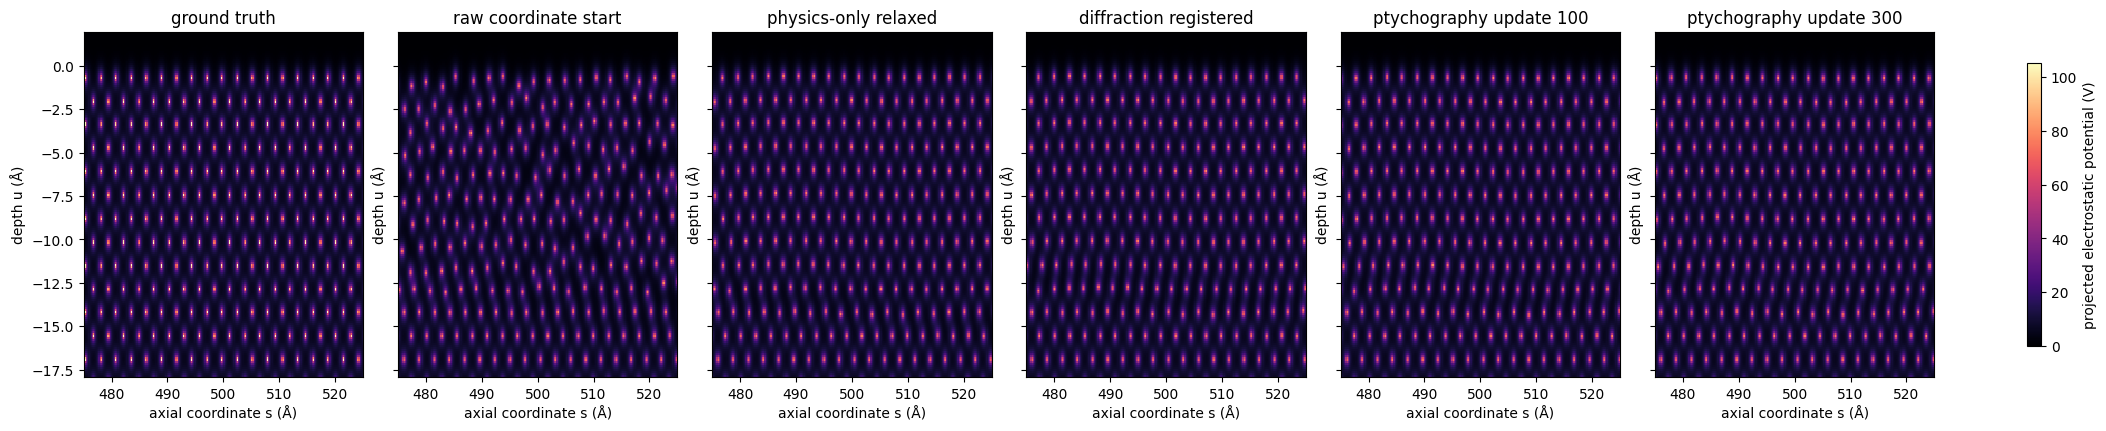

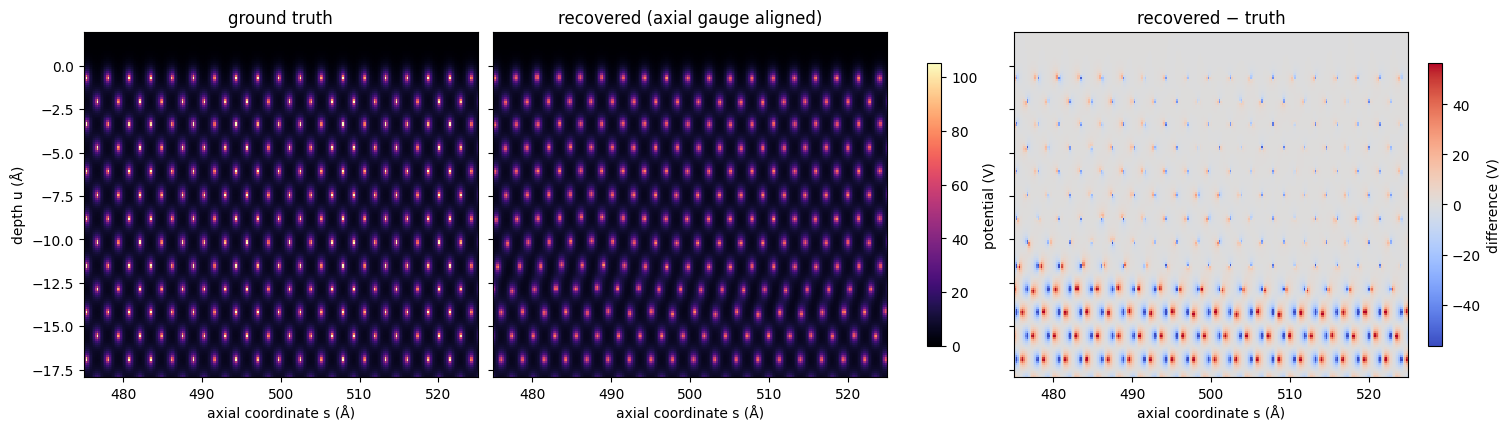

In [10]:
aligned_recovered_potential = shift_image(
    np.asarray(crystal_result.potential),
    shift=(gauge_translation_A[0] / ds, 0.0),
    order=1,
    mode="constant",
    cval=0.0,
)
zoom_s = np.flatnonzero((crop_s_A >= 475.0) & (crop_s_A <= 525.0))
zoom_u = np.flatnonzero((u_A >= -18.0) & (u_A <= 2.0))
zoom_extent = [
    float(crop_s_A[zoom_s[0]]), float(crop_s_A[zoom_s[-1]]),
    float(u_A[zoom_u[0]]), float(u_A[zoom_u[-1]]),
]
truth_zoom = np.asarray(truth_crop_potential)[np.ix_(zoom_s, zoom_u)].T
potential_vmax = float(np.percentile(truth_zoom[truth_zoom > 0], 99.7))

display_stages = [
    ("raw coordinate start", raw_initial_host_A),
    ("physics-only relaxed", physics_relaxed_host_A),
    ("diffraction registered", registered_host_A),
]
checkpoint_indices = [
    int(np.flatnonzero(np.asarray(crystal_result.update_history) == update)[0])
    for update in (100, 300)
]
display_stages.extend([
    (
        f"ptychography update {int(crystal_result.update_history[index])}",
        transform_crystalline_host_1d(
            crystal_model.host_reference_positions_3d,
            crystal_result.translation_history[index],
            crystal_result.strain_history[index],
            crystal_result.rotation_history[index],
            crystal_result.host_displacement_history[index],
            host_update_weights,
        ),
    )
    for index in checkpoint_indices
])

fig, axes = plt.subplots(
    1, 1 + len(display_stages), figsize=(21, 4.2),
    constrained_layout=True, sharex=True, sharey=True,
)
truth_artist = axes[0].imshow(
    truth_zoom, origin="lower", aspect="auto", extent=zoom_extent,
    cmap="magma", vmin=0.0, vmax=potential_vmax, interpolation="nearest",
)
axes[0].set_title("ground truth")
for axis, (title, positions) in zip(axes[1:], display_stages):
    stage_potential = np.asarray(render_crystalline_host_1d(
        topology_model, positions
    ))
    stage_aligned = shift_image(
        stage_potential,
        shift=(gauge_translation_A[0] / ds, 0.0),
        order=1,
        mode="constant",
        cval=0.0,
    )
    axis.imshow(
        stage_aligned[np.ix_(zoom_s, zoom_u)].T,
        origin="lower", aspect="auto", extent=zoom_extent,
        cmap="magma", vmin=0.0, vmax=potential_vmax,
        interpolation="nearest",
    )
    axis.set_title(title)
for axis in axes:
    axis.set(xlabel="axial coordinate s (Å)", ylabel="depth u (Å)")
fig.colorbar(
    truth_artist, ax=axes, shrink=0.82,
    label="projected electrostatic potential (V)",
)

potential_difference = aligned_recovered_potential - np.asarray(
    truth_crop_potential
)
difference_zoom = potential_difference[np.ix_(zoom_s, zoom_u)].T
difference_vmax = float(np.percentile(np.abs(difference_zoom), 99.5))
fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.2), constrained_layout=True, sharex=True, sharey=True
)
images = [
    axes[0].imshow(
        truth_zoom, origin="lower", aspect="auto", extent=zoom_extent,
        cmap="magma", vmin=0, vmax=potential_vmax, interpolation="nearest",
    ),
    axes[1].imshow(
        aligned_recovered_potential[np.ix_(zoom_s, zoom_u)].T,
        origin="lower", aspect="auto", extent=zoom_extent,
        cmap="magma", vmin=0, vmax=potential_vmax, interpolation="nearest",
    ),
    axes[2].imshow(
        difference_zoom, origin="lower", aspect="auto", extent=zoom_extent,
        cmap="coolwarm", vmin=-difference_vmax, vmax=difference_vmax,
        interpolation="nearest",
    ),
]
for axis, title in zip(axes, [
    "ground truth", "recovered (axial gauge aligned)", "recovered − truth"
]):
    axis.set(title=title, xlabel="axial coordinate s (Å)")
axes[0].set_ylabel("depth u (Å)")
fig.colorbar(images[0], ax=axes[:2], shrink=0.82, label="potential (V)")
fig.colorbar(images[2], ax=axes[2], shrink=0.82, label="difference (V)")

## 10. Full reconstruction-volume evolution

The animation below covers the complete loose inverse volume from 100–900 Å and −50–2 Å. The left panel is the full forward truth. The right panel begins with the deliberately distorted coordinates, then shows physics-only relaxation, diffraction registration, and every stored ptychographic checkpoint. The cyan contour is the 0.5 update-weight boundary: it is empty before the first 400 Å landing, grows while landings accumulate from 400–600 Å, and continues after 600 Å along the post-landing rays. The grey overlay is non-updatable; completely grey sites remain exactly at their starting prior. Frames are downsampled only for display; reconstruction and diffraction evaluation retain the full grid.

The same final axial gauge is applied to every recovered frame. No depth shift is allowed, so the surface termination remains fixed throughout the animation.

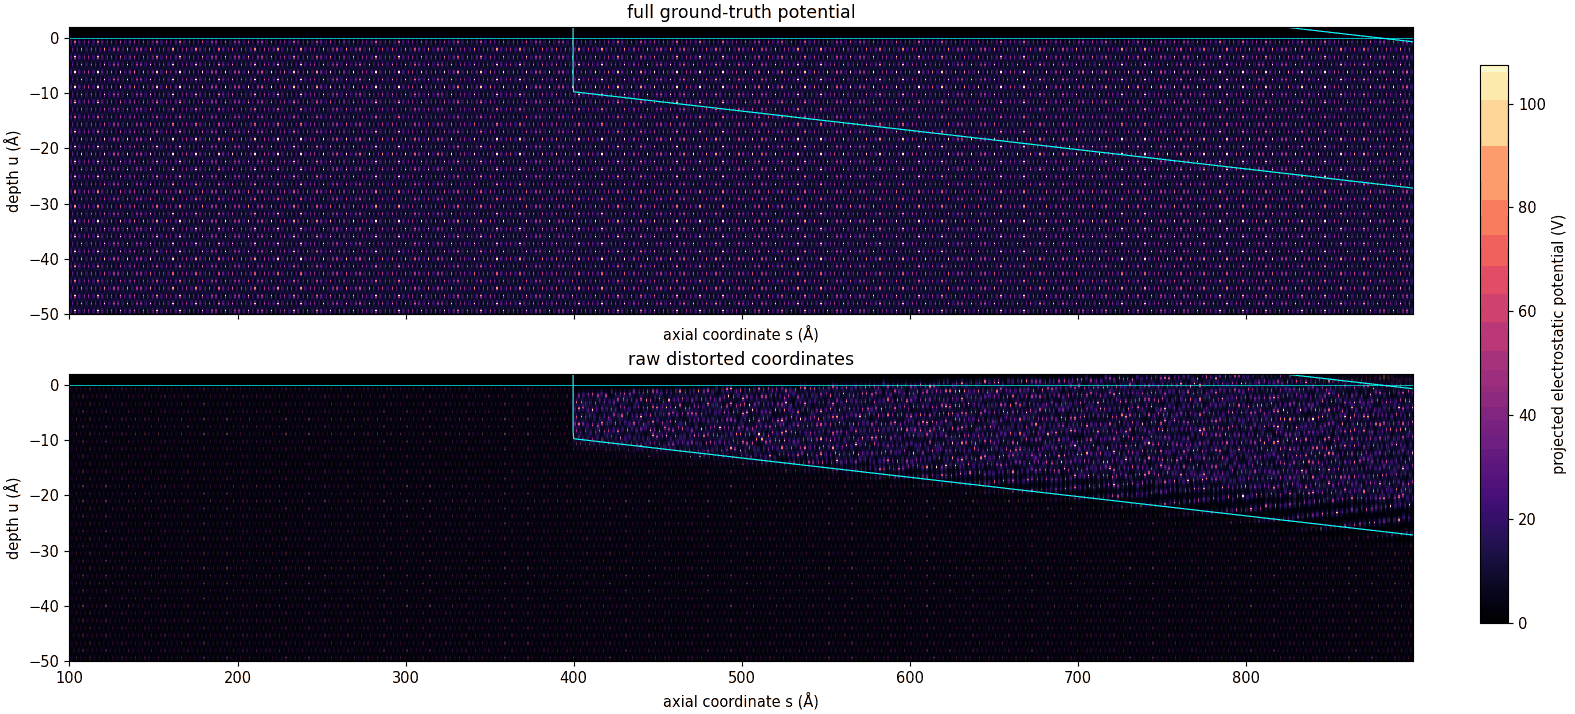

/home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_ptychography_1d/pristine_si_full_wedge_post_landing_v6.gif


In [11]:
full_wedge_gif_path = (
    result_directory / "pristine_si_full_wedge_post_landing_v6.gif"
)
if not full_wedge_gif_path.exists():
    full_wedge_s_indices = np.arange(0, len(crop_s_A), 4)
    full_wedge_u_indices = np.flatnonzero((u_A >= -50.0) & (u_A <= 2.0))[::2]
    full_wedge_extent = [
        float(crop_s_A[full_wedge_s_indices[0]]),
        float(crop_s_A[full_wedge_s_indices[-1]]),
        float(u_A[full_wedge_u_indices[0]]),
        float(u_A[full_wedge_u_indices[-1]]),
    ]
    full_truth_frame = np.asarray(truth_crop_potential)[np.ix_(
        full_wedge_s_indices, full_wedge_u_indices
    )].T.astype(np.float32)
    full_wedge_s_A = crop_s_A[full_wedge_s_indices]
    full_wedge_u_A = u_A[full_wedge_u_indices]
    display_ray_u_A = (
        beam_centres_A[None, None, :]
        + full_wedge_s_A[None, :, None] * np.tan(beam_tilt_rad)
    )
    display_ray_is_post_landing = (
        full_wedge_s_A[None, :, None] >= scan_coordinates_A[None, None, :]
    )
    display_ray_distance_A = np.min(
        np.where(
            display_ray_is_post_landing,
            np.abs(full_wedge_u_A[:, None, None] - display_ray_u_A),
            np.inf,
        ),
        axis=2,
    )
    display_update_fraction = np.clip(
        (update_outer_radius_A - display_ray_distance_A)
        / (update_outer_radius_A - update_inner_radius_A), 0.0, 1.0,
    )
    full_wedge_update_weights = (
        display_update_fraction**2 * (3.0 - 2.0 * display_update_fraction)
    )

    full_wedge_stage_positions = [
        ("raw distorted coordinates", raw_initial_host_A),
        ("physics-only Keating relaxation", physics_relaxed_host_A),
    ]
    for checkpoint_index, checkpoint_update in enumerate(
        np.asarray(crystal_result.update_history)
    ):
        checkpoint_positions = transform_crystalline_host_1d(
            crystal_model.host_reference_positions_3d,
            crystal_result.translation_history[checkpoint_index],
            crystal_result.strain_history[checkpoint_index],
            crystal_result.rotation_history[checkpoint_index],
            crystal_result.host_displacement_history[checkpoint_index],
            host_update_weights,
        )
        checkpoint_label = (
            "diffraction registered / update 0"
            if int(checkpoint_update) == 0
            else f"ptychography update {int(checkpoint_update)}"
        )
        full_wedge_stage_positions.append(
            (checkpoint_label, checkpoint_positions)
        )

    full_wedge_frames = []
    full_wedge_labels = []
    for frame_label, frame_positions in full_wedge_stage_positions:
        gauge_aligned_positions = jnp.asarray(frame_positions).at[:, 0].add(
            gauge_translation_A[0]
        )
        frame_potential = np.asarray(render_crystalline_host_1d(
            topology_model, gauge_aligned_positions
        ))
        full_wedge_frames.append(
            frame_potential[np.ix_(
                full_wedge_s_indices, full_wedge_u_indices
            )].T.astype(np.float32)
        )
        full_wedge_labels.append(frame_label)
    full_wedge_frames = np.stack(full_wedge_frames)
    full_wedge_vmax = float(np.percentile(
        full_truth_frame[full_truth_frame > 0], 99.7
    ))

    with plt.ioff():
        full_wedge_figure, full_wedge_axes = plt.subplots(
            2, 1, figsize=(15, 6.8), constrained_layout=True,
            sharex=True, sharey=True,
        )
    truth_artist = full_wedge_axes[0].imshow(
        full_truth_frame,
        origin="lower",
        aspect="auto",
        extent=full_wedge_extent,
        cmap="magma",
        vmin=0.0,
        vmax=full_wedge_vmax,
        interpolation="nearest",
    )
    recovered_artist = full_wedge_axes[1].imshow(
        full_wedge_frames[0],
        origin="lower",
        aspect="auto",
        extent=full_wedge_extent,
        cmap="magma",
        vmin=0.0,
        vmax=full_wedge_vmax,
        interpolation="nearest",
    )
    full_wedge_axes[1].imshow(
        np.ones_like(full_wedge_update_weights),
        origin="lower", aspect="auto", extent=full_wedge_extent,
        cmap="Greys", vmin=0.0, vmax=1.0,
        alpha=0.72 * (1.0 - full_wedge_update_weights),
        interpolation="nearest",
    )
    for axis in full_wedge_axes:
        axis.contour(
            full_wedge_s_A, full_wedge_u_A, full_wedge_update_weights,
            levels=[0.5], colors=["cyan"], linewidths=0.8,
        )
    full_wedge_axes[0].set_title("full ground-truth potential")
    recovered_title = full_wedge_axes[1].set_title(
        full_wedge_labels[0]
    )
    for axis in full_wedge_axes:
        axis.axhline(0.0, color="cyan", lw=0.7, alpha=0.7)
        axis.set(
            xlabel="axial coordinate s (Å)",
            ylabel="depth u (Å)",
        )
    full_wedge_figure.colorbar(
        truth_artist,
        ax=full_wedge_axes,
        shrink=0.88,
        label="projected electrostatic potential (V)",
    )

    def update_full_wedge(frame_index):
        recovered_artist.set_data(full_wedge_frames[frame_index])
        recovered_title.set_text(full_wedge_labels[frame_index])
        return recovered_artist, recovered_title

    full_wedge_animation = FuncAnimation(
        full_wedge_figure,
        update_full_wedge,
        frames=len(full_wedge_frames),
        interval=450,
        blit=False,
    )
    full_wedge_animation.save(
        full_wedge_gif_path, writer="pillow", fps=2.2, dpi=105
    )
    plt.close(full_wedge_figure)

display(Image(filename=str(full_wedge_gif_path)))
print(full_wedge_gif_path)

### Cached full-wedge animation

![Full post-landing-masked pristine-silicon reconstruction evolution](../notebook_results/sideview_glancing_ptychography_1d/pristine_si_full_wedge_post_landing_v6.gif)

## 11. Linear diffraction residual and optimization diagnostics

No logarithm is used in the diffraction panels. The residual is the signed recovered-minus-measured intensity. The second figure checks that the data improvement did not come from destroying the Si lattice.

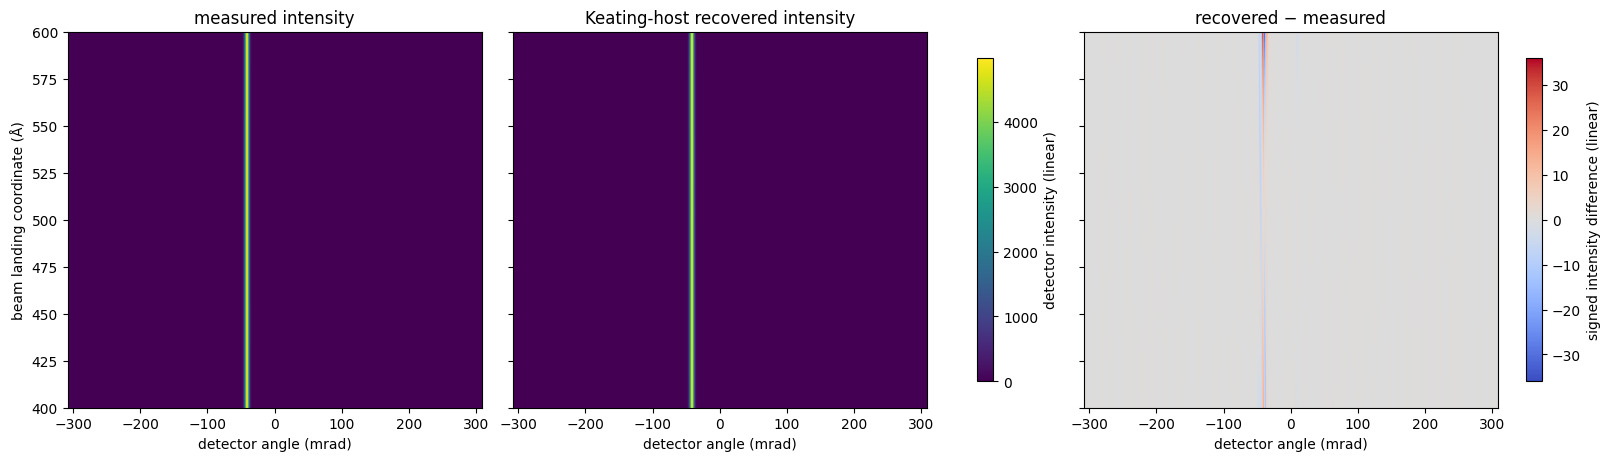

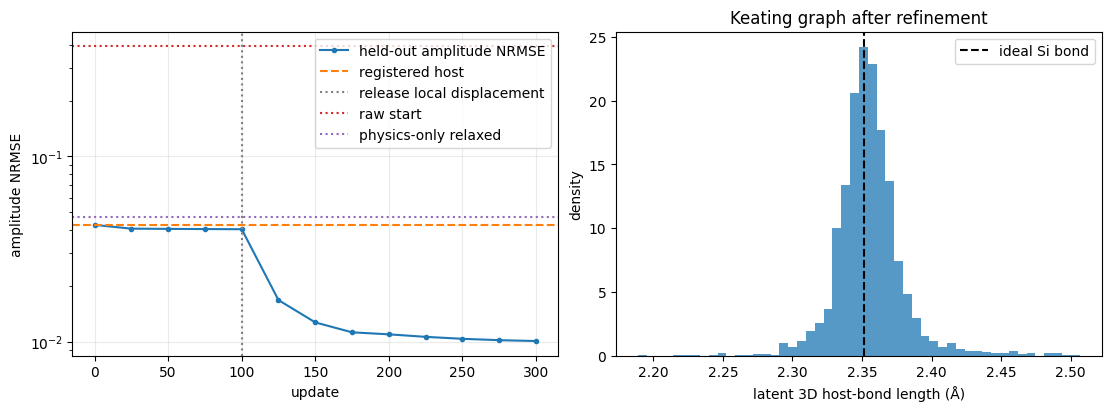

In [12]:
measured_diffraction = np.asarray(scan.intensities)
recovered_diffraction = np.asarray(crystal_result.predicted_intensities)
diffraction_difference = recovered_diffraction - measured_diffraction
intensity_vmax = float(np.max(measured_diffraction))
difference_vmax = float(np.max(np.abs(diffraction_difference)))
diffraction_extent = [
    float(scan.detector_angles[0]), float(scan.detector_angles[-1]),
    float(scan.scan_coordinates[0]), float(scan.scan_coordinates[-1]),
]

fig, axes = plt.subplots(
    1, 3, figsize=(16, 4.5), constrained_layout=True, sharey=True
)
images = [
    axes[0].imshow(
        measured_diffraction, origin="lower", aspect="auto",
        extent=diffraction_extent, cmap="viridis", vmin=0,
        vmax=intensity_vmax,
    ),
    axes[1].imshow(
        recovered_diffraction, origin="lower", aspect="auto",
        extent=diffraction_extent, cmap="viridis", vmin=0,
        vmax=intensity_vmax,
    ),
    axes[2].imshow(
        diffraction_difference, origin="lower", aspect="auto",
        extent=diffraction_extent, cmap="coolwarm",
        vmin=-difference_vmax, vmax=difference_vmax,
    ),
]
for axis, title in zip(axes, [
    "measured intensity", "Keating-host recovered intensity",
    "recovered − measured",
]):
    axis.set(title=title, xlabel="detector angle (mrad)")
axes[0].set_ylabel("beam landing coordinate (Å)")
fig.colorbar(
    images[0], ax=axes[:2], shrink=0.86,
    label="detector intensity (linear)",
)
fig.colorbar(
    images[2], ax=axes[2], shrink=0.86,
    label="signed intensity difference (linear)",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].semilogy(
    crystal_result.update_history,
    crystal_result.validation_loss_history,
    marker="o",
    ms=3,
    label="held-out amplitude NRMSE",
)
axes[0].axhline(
    coarse_validation_nrmse, color="tab:orange", ls="--",
    label="registered host",
)
axes[0].axvline(100, color="0.5", ls=":", label="release local displacement")
axes[0].axhline(raw_validation_nrmse, color="tab:red", ls=":", label="raw start")
axes[0].axhline(physics_relaxed_validation_nrmse, color="tab:purple", ls=":", label="physics-only relaxed")
axes[0].set(xlabel="update", ylabel="amplitude NRMSE")
axes[0].grid(alpha=0.25)
axes[0].legend()
axes[1].hist(
    recovered_bond_lengths_A, bins=50, density=True,
    color="tab:blue", alpha=0.75,
)
axes[1].axvline(
    si_bond_A, color="k", ls="--", label="ideal Si bond"
)
axes[1].set(
    xlabel="latent 3D host-bond length (Å)", ylabel="density",
    title="Keating graph after refinement",
)
axes[1].legend()

## Interpretation

The poor-start experiment separates what the lattice prior supplies from what ptychography supplies. Keating relaxation alone restores the Si bond network but leaves rigid phase and rotation unresolved, so its diffraction mismatch remains large. The training-only registration then supplies those global coordinates, and the final diffraction refinement reaches 1.008% held-out amplitude error while retaining the surface planes and a narrow bond distribution. This is just above the strict 1% gate and below the 1.141% mismatch obtained by simply cropping the exact forward potential to the loose inverse volume.

The method still assumes the lattice it is trying to refine. Diamond topology, the silicon bond length, approximate orientation, atom count from volume, and the (100) termination are inputs. The fixed graph does not discover whether the specimen is diamond, amorphous, another Si polymorph, or a different orientation. A less supervised workflow would first index lattice spacing and orientation from diffraction and compare candidate graphs. A genuinely lattice-free model would need dynamic neighbors or a bond-order potential that enforces local tetrahedral coordination without prescribing sites; that is a harder inverse problem than the one demonstrated here.

Finally, only axial translation is removed for structural display. The surface-normal position is physically meaningful, and allowing a depth gauge was the plotting error that previously hid the first two surface rows. The present reconstruction also makes observability explicit: the diffraction data and Keating prior update coordinates only inside the union of post-landing half-rays. No bulk coordinate before 400 Å is updated; the support grows across the 400–600 Å landing interval and then continues downstream. The remainder of the loose box is displayed for context but is frozen at the assumed diamond-host prior and excluded from structural scores; it is not a claimed reconstruction.